# DNA Species Classifier: Neural Network using PyTorch


##  Setup

In [1]:
import os, random, time, copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader



In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, classification_report, f1_score, accuracy_score, precision_recall_fscore_support)
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier


In [ ]:
# ---- paths
DATA_DIR = r"D:\TECH405\DNASequences\DataSets"
FIG_DIR  = "figures"
os.makedirs(FIG_DIR, exist_ok=True)

SEED   = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

set_seed()
sns.set_theme(style="whitegrid")

Device: cpu


## Loading the data produced by the EDA.ipynb file

In [4]:
train_df = pd.read_csv(os.path.join(DATA_DIR, "train_balanced.csv"))
val_df   = pd.read_csv(os.path.join(DATA_DIR, "val_final.csv"))
test_df  = pd.read_csv(os.path.join(DATA_DIR, "test_final.csv"))

classes   = sorted(train_df["class"].unique())
label_map = {c: i for i, c in enumerate(classes)}
num_classes = len(classes)

y_train = train_df["class"].map(label_map).values
y_val   = val_df["class"].map(label_map).values
y_test  = test_df["class"].map(label_map).values

y_train_t = torch.tensor(y_train, dtype=torch.long)
y_val_t   = torch.tensor(y_val,   dtype=torch.long)
y_test_t  = torch.tensor(y_test,  dtype=torch.long)

print(label_map)
summary = pd.DataFrame({
    "train": train_df["class"].value_counts(),
    "val":   val_df["class"].value_counts(),
    "test":  test_df["class"].value_counts(),
}).fillna(0).astype(int)
summary

{'Bos taurus': 0, 'Canis lupus': 1, 'Felis catus': 2, 'Homo sapiens': 3, 'Pan troglodytes': 4}


,train,val,test
class,,,
Bos taurus,850,64,65
Canis lupus,1496,122,123
Felis catus,349,7,6
Homo sapiens,1500,544,544
Pan troglodytes,1489,251,251


## Feature engineering: k-mer frequency vectors


1. **Implementation of vocabulary of 4^k k-mers made only of A/C/G/T.** 
2. **Optional standardisation** (fit on train only) because raw frequencies are tiny numbers, which makes training unstable.

In [5]:
BASE_MAP = np.full(256, -1, dtype=np.int64)
for i, b in enumerate("ACGT"):
    BASE_MAP[ord(b)] = i
    BASE_MAP[ord(b.lower())] = i

def kmer_vector(seq, k):
    """Normalised frequency vector over all 4**k A/C/G/T k-mers."""
    vec = np.zeros(4 ** k, dtype=np.float32)
    arr = BASE_MAP[np.frombuffer(str(seq).encode("ascii", "ignore"), dtype=np.uint8)]
    n = len(arr) - k + 1
    if n <= 0:
        return vec
    idx = np.zeros(n, dtype=np.int64)
    valid = np.ones(n, dtype=bool)
    for j in range(k):
        seg = arr[j:j + n]
        valid &= seg >= 0
        idx = idx * 4 + np.where(seg >= 0, seg, 0)
    counts = np.bincount(idx[valid], minlength=4 ** k)
    total = counts.sum()
    return (counts / total).astype(np.float32) if total > 0 else vec

def build_features(seqs, k):
    return np.vstack([kmer_vector(s, k) for s in seqs])

_data_cache = {}
def get_data(k, scale=True):
    """Build (and cache) tensors for a given k. The scaler is fit on train only."""
    key = (k, scale)
    if key in _data_cache:
        return _data_cache[key]
    Xtr = build_features(train_df["sequence"], k)
    Xva = build_features(val_df["sequence"], k)
    Xte = build_features(test_df["sequence"], k)
    scaler = None
    if scale:
        scaler = StandardScaler().fit(Xtr)
        Xtr, Xva, Xte = scaler.transform(Xtr), scaler.transform(Xva), scaler.transform(Xte)
    to_t = lambda a: torch.tensor(a, dtype=torch.float32)
    _data_cache[key] = dict(X_train=to_t(Xtr), X_val=to_t(Xva), X_test=to_t(Xte), scaler=scaler)
    return _data_cache[key]

d = get_data(5, True)
print("Feature shapes:", d["X_train"].shape, d["X_val"].shape, d["X_test"].shape)

Feature shapes: torch.Size([5684, 1024]) torch.Size([988, 1024]) torch.Size([989, 1024])


## Model, training and evaluation :

- `DNAClassifier`: an MLP whose hidden sizes, dropout and batch-norm are configurable, so the same class serves every experiment.
- `train_model(cfg)`: trains with **early stopping on validation macro-F1** and restores the best checkpoint.
- Loss is reported as the **mean per sample**, so runs with different batch sizes are comparable.

In [6]:
class DNAClassifier(nn.Module):
    def __init__(self, input_size, num_classes, hidden=(128, 64), dropout=0.3, batchnorm=False):
        super().__init__()
        layers, prev = [], input_size
        for h in hidden:
            layers.append(nn.Linear(prev, h))
            if batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers += [nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, num_classes))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


@torch.no_grad()
def predict_logits(model, X, batch_size=512):
    model.eval()
    out = [model(X[i:i + batch_size].to(DEVICE)).cpu() for i in range(0, len(X), batch_size)]
    return torch.cat(out)


BASELINE = dict(
    k=5, scale=True,
    hidden=(128, 64), dropout=0.3, batchnorm=False,
    optimizer="adam", lr=1e-3, weight_decay=0.0,
    batch_size=64, epochs=40, patience=8,
    class_weight=False,
)


def train_model(overrides=None, verbose=False):
    cfg = {**BASELINE, **(overrides or {})}
    set_seed(SEED)
    data = get_data(cfg["k"], cfg["scale"])

    model = DNAClassifier(data["X_train"].shape[1], num_classes,
                          cfg["hidden"], cfg["dropout"], cfg["batchnorm"]).to(DEVICE)

    weight = None
    if cfg["class_weight"]:
        counts = np.bincount(y_train, minlength=num_classes)
        weight = torch.tensor(counts.sum() / (num_classes * counts), dtype=torch.float32, device=DEVICE)
    criterion = nn.CrossEntropyLoss(weight=weight)

    if cfg["optimizer"] == "adam":
        opt = torch.optim.Adam(model.parameters(), lr=cfg["lr"], weight_decay=cfg["weight_decay"])
    elif cfg["optimizer"] == "sgd":
        opt = torch.optim.SGD(model.parameters(), lr=cfg["lr"], momentum=0.9, weight_decay=cfg["weight_decay"])
    else:
        raise ValueError("optimizer must be 'adam' or 'sgd'")

    gen = torch.Generator(); gen.manual_seed(SEED)
    loader = DataLoader(TensorDataset(data["X_train"], y_train_t), batch_size=cfg["batch_size"],
                        shuffle=True, generator=gen, drop_last=cfg["batchnorm"])

    hist = {k: [] for k in ["train_loss", "train_acc", "val_loss", "val_acc", "val_f1"]}
    best = dict(f1=-1, state=None, epoch=0)
    bad, t0 = 0, time.time()

    for epoch in range(1, cfg["epochs"] + 1):
        model.train()
        run_loss, correct, n = 0.0, 0, 0
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            opt.step()
            run_loss += loss.item() * len(yb)
            correct  += (out.argmax(1) == yb).sum().item()
            n += len(yb)

        v_logits = predict_logits(model, data["X_val"])
        v_pred   = v_logits.argmax(1).numpy()
        v_loss   = F.cross_entropy(v_logits, y_val_t).item()
        v_acc    = accuracy_score(y_val, v_pred)
        v_f1     = f1_score(y_val, v_pred, average="macro", zero_division=0)

        hist["train_loss"].append(run_loss / n); hist["train_acc"].append(correct / n)
        hist["val_loss"].append(v_loss);         hist["val_acc"].append(v_acc); hist["val_f1"].append(v_f1)

        if verbose:
            print(f"Epoch {epoch:02d} | train loss {run_loss/n:.4f} acc {correct/n:.3f} | "
                  f"val loss {v_loss:.4f} acc {v_acc:.3f} macro-F1 {v_f1:.3f}")

        if v_f1 > best["f1"]:
            best.update(f1=v_f1, state=copy.deepcopy(model.state_dict()), epoch=epoch); bad = 0
        else:
            bad += 1
            if bad >= cfg["patience"]:
                break

    model.load_state_dict(best["state"])
    b = best["epoch"] - 1
    return dict(cfg=cfg, model=model, history=hist, best_epoch=best["epoch"], epochs_run=len(hist["val_f1"]),
                val_f1=hist["val_f1"][b], val_acc=hist["val_acc"][b], train_acc=hist["train_acc"][b],
                seconds=time.time() - t0)


def plot_history(res, title="Training curves", save_as=None):
    h = res["history"]; ep = range(1, len(h["train_loss"]) + 1)
    fig, ax = plt.subplots(1, 3, figsize=(16, 4))
    ax[0].plot(ep, h["train_loss"], label="train"); ax[0].plot(ep, h["val_loss"], label="val")
    ax[0].set_title("Loss (mean per sample)"); ax[0].set_xlabel("epoch"); ax[0].legend()
    ax[1].plot(ep, h["train_acc"], label="train"); ax[1].plot(ep, h["val_acc"], label="val")
    ax[1].set_title("Accuracy"); ax[1].set_xlabel("epoch"); ax[1].legend()
    ax[2].plot(ep, h["val_f1"], color="tab:green"); ax[2].axvline(res["best_epoch"], ls="--", color="grey")
    ax[2].set_title("Validation macro-F1 (dashed = best epoch)"); ax[2].set_xlabel("epoch")
    fig.suptitle(title); plt.tight_layout()
    if save_as: plt.savefig(os.path.join(FIG_DIR, save_as), dpi=150)
    plt.show()

Epoch 01 | train loss 1.1048 acc 0.457 | val loss 1.0244 acc 0.515 macro-F1 0.487
Epoch 02 | train loss 0.7792 acc 0.646 | val loss 1.0070 acc 0.558 macro-F1 0.532
Epoch 03 | train loss 0.6029 acc 0.743 | val loss 1.1751 acc 0.540 macro-F1 0.520
Epoch 04 | train loss 0.4599 acc 0.812 | val loss 1.4040 acc 0.535 macro-F1 0.530
Epoch 05 | train loss 0.3622 acc 0.856 | val loss 1.6486 acc 0.533 macro-F1 0.518
Epoch 06 | train loss 0.2862 acc 0.888 | val loss 1.8563 acc 0.534 macro-F1 0.535
Epoch 07 | train loss 0.2287 acc 0.914 | val loss 1.9860 acc 0.507 macro-F1 0.522
Epoch 08 | train loss 0.1927 acc 0.931 | val loss 1.9878 acc 0.502 macro-F1 0.551
Epoch 09 | train loss 0.1476 acc 0.951 | val loss 2.3326 acc 0.524 macro-F1 0.536
Epoch 10 | train loss 0.1325 acc 0.957 | val loss 2.4320 acc 0.518 macro-F1 0.526
Epoch 11 | train loss 0.1175 acc 0.961 | val loss 2.4200 acc 0.524 macro-F1 0.534
Epoch 12 | train loss 0.1132 acc 0.964 | val loss 2.5007 acc 0.524 macro-F1 0.535
Epoch 13 | train

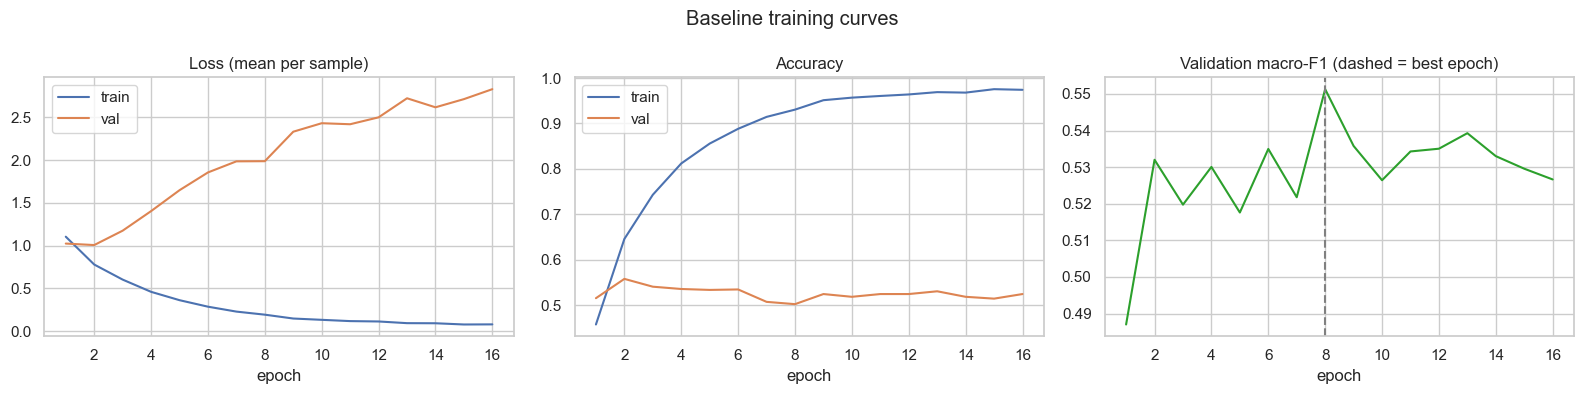

In [7]:
baseline = train_model({}, verbose=True)
print(f"\nBest epoch {baseline['best_epoch']} | val macro-F1 {baseline['val_f1']:.3f} | val acc {baseline['val_acc']:.3f}")
plot_history(baseline, "Baseline training curves", "baseline_curves.png")

## Hyperparameter experiments


In [8]:
experiments = [("baseline", "baseline", {})]

for lr in [1e-2, 1e-4]:
    experiments.append(("learning_rate", f"lr={lr}", {"lr": lr}))
for hid in [(64,), (256, 128), (512, 256, 128)]:
    experiments.append(("architecture", f"hidden={hid}", {"hidden": hid}))
for dp in [0.0, 0.5]:
    experiments.append(("dropout", f"dropout={dp}", {"dropout": dp}))
for bs in [32, 256]:
    experiments.append(("batch_size", f"batch={bs}", {"batch_size": bs}))
for wd in [1e-4, 1e-3]:
    experiments.append(("weight_decay", f"wd={wd}", {"weight_decay": wd}))
experiments.append(("optimizer", "sgd+momentum", {"optimizer": "sgd", "lr": 1e-2}))
experiments.append(("batchnorm", "batchnorm=True", {"batchnorm": True}))
experiments.append(("loss", "class_weight=True", {"class_weight": True}))
experiments.append(("input_scaling", "no scaling", {"scale": False}))
for k in [3, 4, 6]:
    experiments.append(("kmer_size", f"k={k}", {"k": k}))

results = {}
for group, name, ov in experiments:
    print(f"Running {name:<22}", end=" ")
    results[name] = train_model(ov)
    r = results[name]
    print(f"-> val macro-F1 {r['val_f1']:.3f} | val acc {r['val_acc']:.3f} | best epoch {r['best_epoch']}/{r['epochs_run']} | {r['seconds']:.0f}s")

log = pd.DataFrame([{
    "group": g, "run": n,
    "val_macro_f1": results[n]["val_f1"], "val_acc": results[n]["val_acc"],
    "train_acc": results[n]["train_acc"],
    "best_epoch": results[n]["best_epoch"], "epochs_run": results[n]["epochs_run"],
    "seconds": round(results[n]["seconds"], 1),
} for g, n, _ in experiments])
log.to_csv("experiment_log.csv", index=False)
log.sort_values("val_macro_f1", ascending=False).reset_index(drop=True)

Running baseline               -> val macro-F1 0.551 | val acc 0.502 | best epoch 8/16 | 4s
Running lr=0.01                -> val macro-F1 0.541 | val acc 0.467 | best epoch 11/19 | 6s
Running lr=0.0001              -> val macro-F1 0.530 | val acc 0.534 | best epoch 17/25 | 11s
Running hidden=(64,)           -> val macro-F1 0.538 | val acc 0.512 | best epoch 3/11 | 10s
Running hidden=(256, 128)      -> val macro-F1 0.536 | val acc 0.536 | best epoch 7/15 | 22s
Running hidden=(512, 256, 128) -> val macro-F1 0.548 | val acc 0.533 | best epoch 3/11 | 25s
Running dropout=0.0            -> val macro-F1 0.550 | val acc 0.436 | best epoch 1/9 | 10s
Running dropout=0.5            -> val macro-F1 0.528 | val acc 0.523 | best epoch 16/24 | 29s
Running batch=32               -> val macro-F1 0.541 | val acc 0.525 | best epoch 9/17 | 34s
Running batch=256              -> val macro-F1 0.533 | val acc 0.529 | best epoch 4/12 | 7s
Running wd=0.0001              -> val macro-F1 0.547 | val acc 0.541 | 

,group,run,val_macro_f1,val_acc,train_acc,best_epoch,epochs_run,seconds
0,input_scaling,no scaling,0.567418,0.504049,0.547502,16,24,31.3
1,baseline,baseline,0.551311,0.502024,0.930507,8,16,4.5
2,dropout,dropout=0.0,0.549610,0.436235,0.504926,1,9,10.1
3,kmer_size,k=6,0.548754,0.555668,0.505278,1,9,4.1
4,architecture,"hidden=(512, 256, 128)",0.548351,0.533401,0.787825,3,11,25.2
5,weight_decay,wd=0.0001,0.546947,0.541498,0.805419,4,12,14.9
6,loss,class_weight=True,0.542621,0.532389,0.775334,4,12,296.5
7,optimizer,sgd+momentum,0.541504,0.526316,0.743666,4,12,10.7
8,batch_size,batch=32,0.541185,0.525304,0.945637,9,17,33.9
9,learning_rate,lr=0.01,0.540817,0.466599,0.745778,11,19,6.1


### Compare the experiments visually

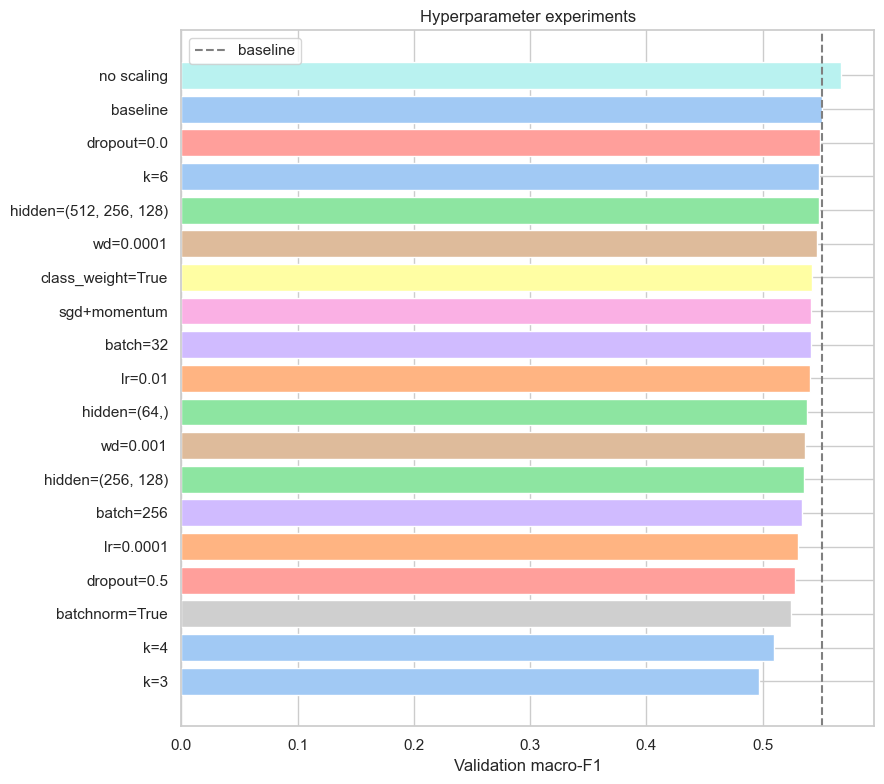

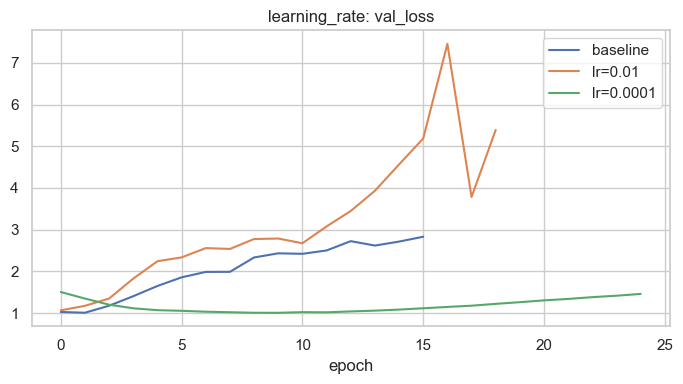

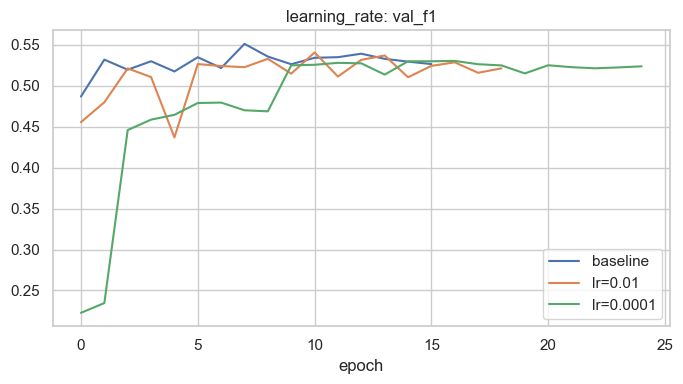

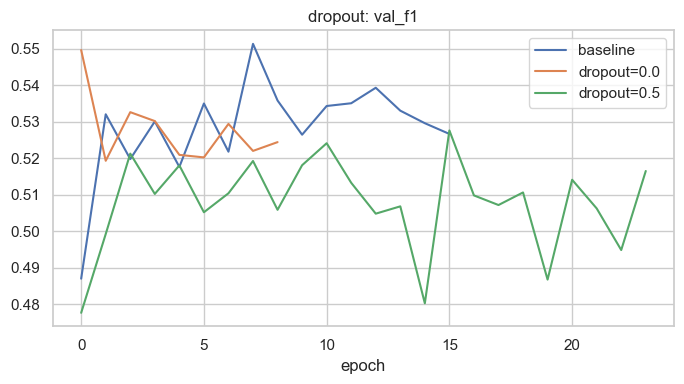

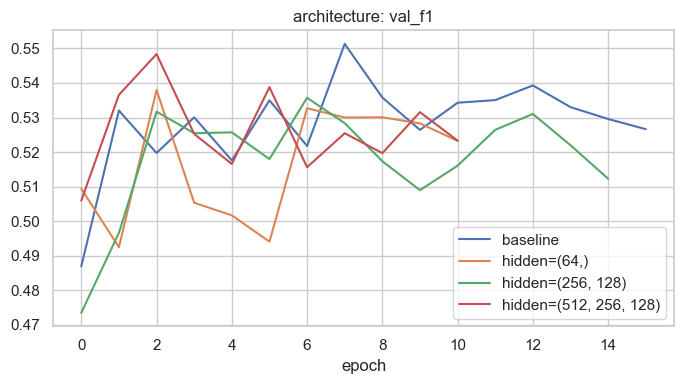

In [9]:
plt.figure(figsize=(9, 8))
order = log.sort_values("val_macro_f1")
colors = sns.color_palette("pastel", n_colors=log["group"].nunique())
cmap = dict(zip(log["group"].unique(), colors))
plt.barh(order["run"], order["val_macro_f1"], color=[cmap[g] for g in order["group"]])
plt.axvline(baseline["val_f1"], ls="--", color="grey", label="baseline")
plt.xlabel("Validation macro-F1"); plt.title("Hyperparameter experiments"); plt.legend()
plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR, "experiments_macro_f1.png"), dpi=150); plt.show()


def plot_group(group, metric="val_loss"):
    """Overlay the validation curves of every run in one experiment group."""
    plt.figure(figsize=(7, 4))
    for g, n, _ in experiments:
        if g == group or n == "baseline":
            plt.plot(results[n]["history"][metric], label=n)
    plt.title(f"{group}: {metric}"); plt.xlabel("epoch"); plt.legend()
    plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR, f"group_{group}_{metric}.png"), dpi=150); plt.show()

plot_group("learning_rate", "val_loss")
plot_group("learning_rate", "val_f1")
plot_group("dropout", "val_f1")
plot_group("architecture", "val_f1")

Combined overrides: {'scale': False}
combined -> val macro-F1 0.567 | val acc 0.504

Selected final model: 'no scaling' (val macro-F1 0.567)
Final configuration: {'k': 5, 'scale': False, 'hidden': (128, 64), 'dropout': 0.3, 'batchnorm': False, 'optimizer': 'adam', 'lr': 0.001, 'weight_decay': 0.0, 'batch_size': 64, 'epochs': 40, 'patience': 8, 'class_weight': False}


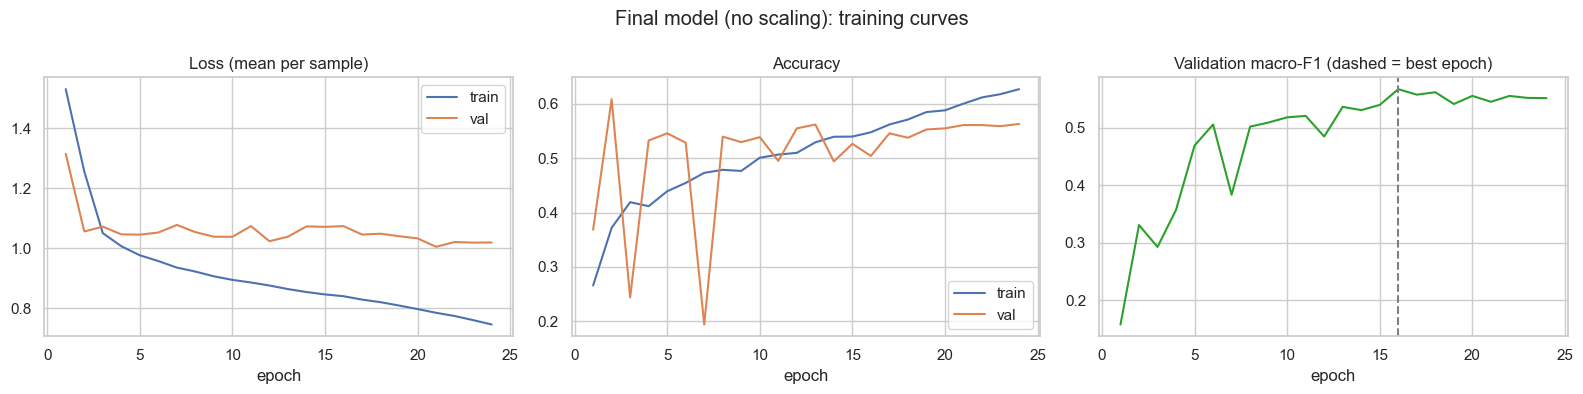

In [10]:
best_per_group = log.loc[log.groupby("group")["val_macro_f1"].idxmax()]
combined_ov = {}
for _, row in best_per_group.iterrows():
    if row["group"] == "baseline":
        continue
    if row["val_macro_f1"] >= baseline["val_f1"]:          # only keep changes that helped
        combined_ov.update({k: v for k, v in results[row["run"]]["cfg"].items()
                            if BASELINE.get(k) != v})
print("Combined overrides:", combined_ov)

results["combined"] = train_model(combined_ov)
print(f"combined -> val macro-F1 {results['combined']['val_f1']:.3f} | val acc {results['combined']['val_acc']:.3f}")

best_name = max(results, key=lambda n: results[n]["val_f1"])
final = results[best_name]
print(f"\nSelected final model: '{best_name}' (val macro-F1 {final['val_f1']:.3f})")
print("Final configuration:", {k: final['cfg'][k] for k in BASELINE})
plot_history(final, f"Final model ({best_name}): training curves", "final_curves.png")

## Validation set performance for final model

This is the last look before the test set. Compare it with the baseline to confirm the tuning helped.

In [11]:
data = get_data(final["cfg"]["k"], final["cfg"]["scale"])
val_pred = predict_logits(final["model"], data["X_val"]).argmax(1).numpy()
print(classification_report(y_val, val_pred, target_names=classes, digits=3, zero_division=0))

                 precision    recall  f1-score   support

     Bos taurus      0.984     0.969     0.976        64
    Canis lupus      0.154     0.336     0.211       122
    Felis catus      1.000     1.000     1.000         7
   Homo sapiens      0.596     0.713     0.649       544
Pan troglodytes      0.000     0.000     0.000       251

       accuracy                          0.504       988
      macro avg      0.547     0.604     0.567       988
   weighted avg      0.418     0.504     0.454       988



## Reference baselines

In [12]:
Xtr, Xva = data["X_train"].numpy(), data["X_val"].numpy()

dummy = DummyClassifier(strategy="most_frequent").fit(Xtr, y_train)
logreg = LogisticRegression(max_iter=2000, class_weight="balanced").fit(Xtr, y_train)

def row(name, pred):
    return {"model": name,
            "val_accuracy": accuracy_score(y_val, pred),
            "val_macro_F1": f1_score(y_val, pred, average="macro", zero_division=0)}

pd.DataFrame([
    row("Majority-class dummy", dummy.predict(Xva)),
    row("Logistic regression (same features)", logreg.predict(Xva)),
    row(f"Neural network ({best_name})", val_pred),
]).round(3)

,model,val_accuracy,val_macro_F1
0,Majority-class dummy,0.551,0.142
1,Logistic regression (same features),0.442,0.480
2,Neural network (no scaling),0.504,0.567


## Final evaluation


In [13]:
test_logits = predict_logits(final["model"], data["X_test"])
y_pred = test_logits.argmax(1).numpy()

print(classification_report(y_test, y_pred, target_names=classes, digits=3, zero_division=0))

p, r, f, s = precision_recall_fscore_support(y_test, y_pred, zero_division=0)
per_class = pd.DataFrame({"precision": p, "recall": r, "f1": f, "support": s}, index=classes).round(3)
per_class.to_csv("test_per_class_metrics.csv")
per_class

                 precision    recall  f1-score   support

     Bos taurus      0.984     0.969     0.977        65
    Canis lupus      0.126     0.260     0.170       123
    Felis catus      0.714     0.833     0.769         6
   Homo sapiens      0.592     0.722     0.651       544
Pan troglodytes      0.000     0.000     0.000       251

       accuracy                          0.498       989
      macro avg      0.483     0.557     0.513       989
   weighted avg      0.410     0.498     0.448       989



,precision,recall,f1,support
Bos taurus,0.984,0.969,0.977,65
Canis lupus,0.126,0.260,0.170,123
Felis catus,0.714,0.833,0.769,6
Homo sapiens,0.592,0.722,0.651,544
Pan troglodytes,0.000,0.000,0.000,251


### Confusion matrices (counts and row-normalised)

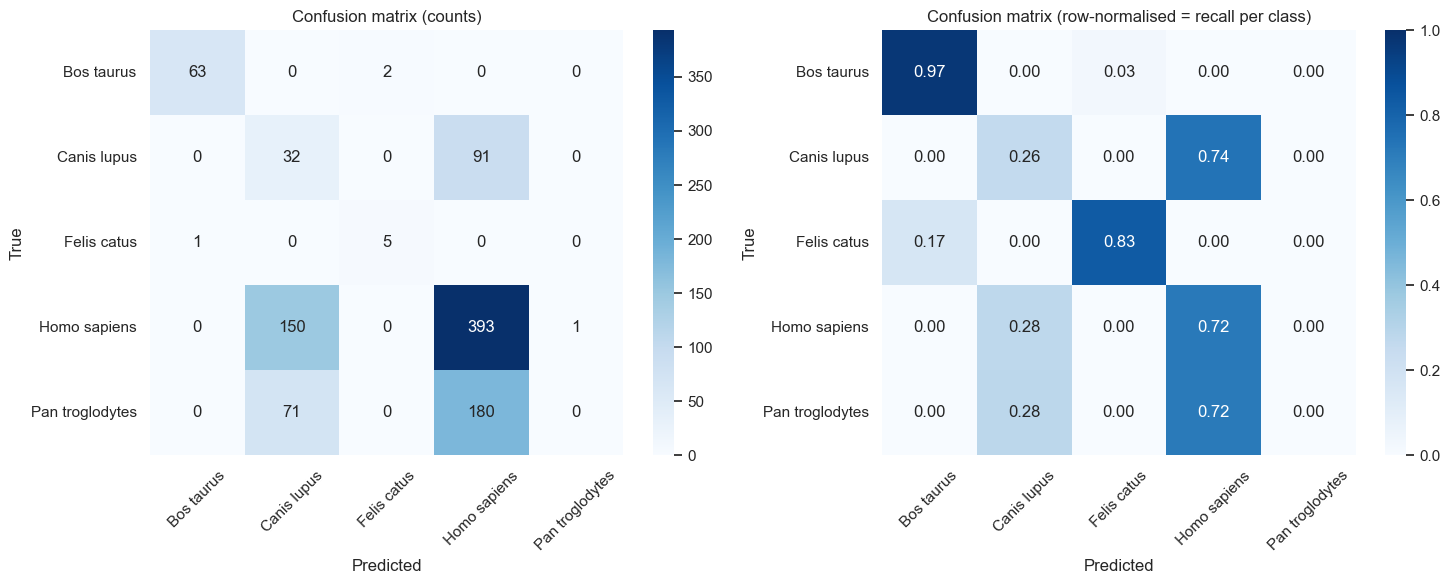

In [14]:
cm = confusion_matrix(y_test, y_pred, labels=range(num_classes))
cm_norm = cm / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(1, 2, figsize=(15, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes, ax=ax[0])
ax[0].set_title("Confusion matrix (counts)")
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1,
            xticklabels=classes, yticklabels=classes, ax=ax[1])
ax[1].set_title("Confusion matrix (row-normalised = recall per class)")
for a in ax:
    a.set_xlabel("Predicted"); a.set_ylabel("True"); a.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR, "confusion_matrix.png"), dpi=150); plt.show()

### Per-class precision / recall / F1

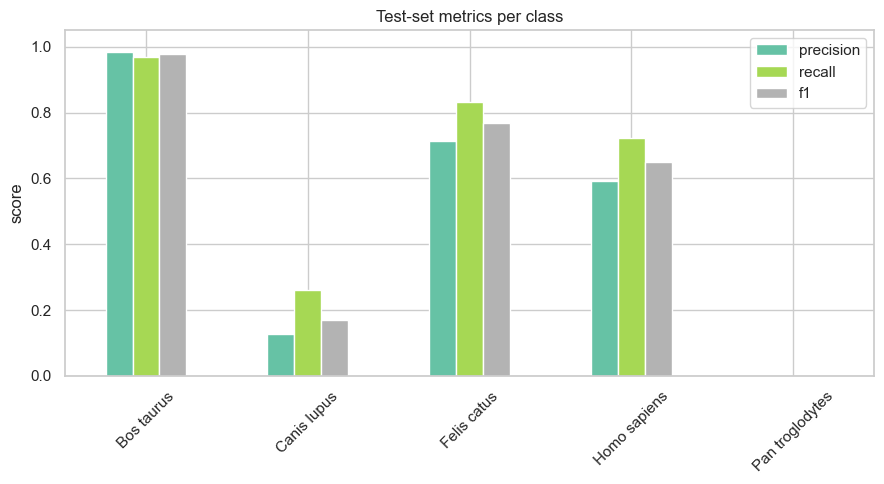

,Accuracy,Macro precision,Macro recall,Macro F1,Weighted F1
0,0.498,0.483,0.557,0.513,0.448


In [15]:
ax = per_class[["precision", "recall", "f1"]].plot(kind="bar", figsize=(9, 5), colormap="Set2")
ax.set_ylim(0, 1.05); ax.set_title("Test-set metrics per class"); ax.set_ylabel("score")
plt.xticks(rotation=45); plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "per_class_metrics.png"), dpi=150); plt.show()

test_summary = pd.DataFrame({
    "Accuracy":  [accuracy_score(y_test, y_pred)],
    "Macro precision": [p.mean()], "Macro recall": [r.mean()],
    "Macro F1": [f1_score(y_test, y_pred, average="macro", zero_division=0)],
    "Weighted F1": [f1_score(y_test, y_pred, average="weighted", zero_division=0)],
}).round(3)
test_summary

## Error analysis: 

In [16]:
pairs = [(classes[i], classes[j], int(cm[i, j]), cm[i, j] / cm[i].sum())
         for i in range(num_classes) for j in range(num_classes) if i != j and cm[i, j] > 0]
errors = (pd.DataFrame(pairs, columns=["true", "predicted_as", "count", "share_of_true_class"])
            .sort_values("count", ascending=False).reset_index(drop=True))
errors.head(8).round(3)

,true,predicted_as,count,share_of_true_class
0,Pan troglodytes,Homo sapiens,180,0.717
1,Homo sapiens,Canis lupus,150,0.276
2,Canis lupus,Homo sapiens,91,0.740
3,Pan troglodytes,Canis lupus,71,0.283
4,Bos taurus,Felis catus,2,0.031
5,Felis catus,Bos taurus,1,0.167
6,Homo sapiens,Pan troglodytes,1,0.002


### Baselines comparison table

In [17]:
Xte = data["X_test"].numpy()
def trow(name, pred):
    return {"model": name, "accuracy": accuracy_score(y_test, pred),
            "macro_F1": f1_score(y_test, pred, average="macro", zero_division=0)}
pd.DataFrame([
    trow("Majority-class dummy", dummy.predict(Xte)),
    trow("Logistic regression", logreg.predict(Xte)),
    trow(f"Neural network ({best_name})", y_pred),
]).round(3)

,model,accuracy,macro_F1
0,Majority-class dummy,0.550,0.142
1,Logistic regression,0.434,0.501
2,Neural network (no scaling),0.498,0.513


## Fixing the window mismatch (train on 200 bp windows, test on whole sequences)

                 precision    recall  f1-score   support

     Bos taurus      0.984     0.969     0.977        65
    Canis lupus      0.154     0.813     0.259       123
    Felis catus      0.714     0.833     0.769         6
   Homo sapiens      0.705     0.347     0.466       544
Pan troglodytes      0.000     0.000     0.000       251

       accuracy                          0.361       989
      macro avg      0.512     0.593     0.494       989
   weighted avg      0.476     0.361     0.357       989



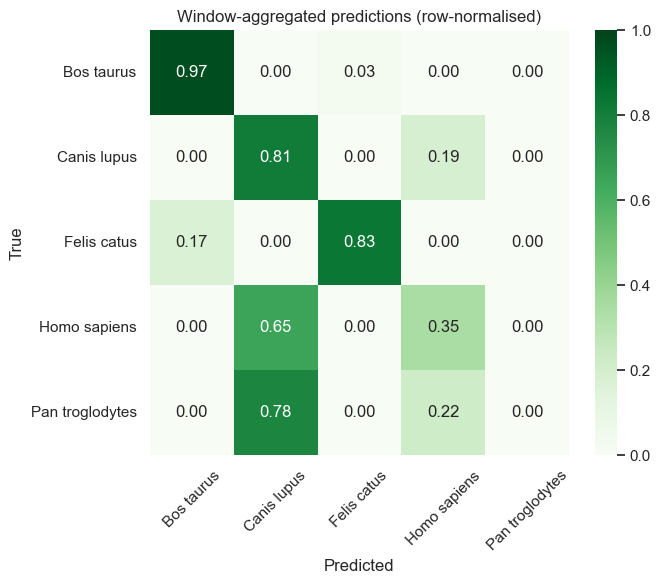

In [18]:
WINDOW, STRIDE = 200, 100

def windowed_predict(model, df, k, scale):
    seqs, owner = [], []
    for i, s in enumerate(df["sequence"]):
        s = str(s)
        if len(s) <= WINDOW:
            seqs.append(s); owner.append(i)
        else:
            for st in range(0, len(s) - WINDOW + 1, STRIDE):
                seqs.append(s[st:st + WINDOW]); owner.append(i)
    X = build_features(seqs, k)
    sc = get_data(k, scale)["scaler"]
    if sc is not None:
        X = sc.transform(X)
    probs = F.softmax(predict_logits(model, torch.tensor(X, dtype=torch.float32)), dim=1).numpy()
    owner = np.array(owner)
    agg = np.vstack([probs[owner == i].mean(axis=0) for i in range(len(df))])
    return agg.argmax(1)

y_pred_win = windowed_predict(final["model"], test_df, final["cfg"]["k"], final["cfg"]["scale"])
print(classification_report(y_test, y_pred_win, target_names=classes, digits=3, zero_division=0))

cm_w = confusion_matrix(y_test, y_pred_win, labels=range(num_classes))
plt.figure(figsize=(7, 6))
sns.heatmap(cm_w / cm_w.sum(axis=1, keepdims=True), annot=True, fmt=".2f", cmap="Greens", vmin=0, vmax=1,
            xticklabels=classes, yticklabels=classes)
plt.title("Window-aggregated predictions (row-normalised)")
plt.xlabel("Predicted"); plt.ylabel("True"); plt.xticks(rotation=45); plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "confusion_matrix_windowed.png"), dpi=150); plt.show()

##  Saving the model

In [19]:
torch.save({"state_dict": final["model"].state_dict(), "config": final["cfg"],
            "classes": classes}, "dna_classifier.pt")
print("Saved dna_classifier.pt | figures in ./figures | logs: experiment_log.csv, test_per_class_metrics.csv")

Saved dna_classifier.pt | figures in ./figures | logs: experiment_log.csv, test_per_class_metrics.csv
